# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, get_top_indices, create_top_sequences, visualize_top_sequences
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor, PreprocessingMode
from src.ml.preprocessing.xthreat import get_default_xt_model


In [35]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [36]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Load Trained Model

In [37]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'  # Change to 'transformer' if using the transformer model
MODEL_DIR = 'generated/attention_lstm_attention_lstm_large_20260214_170158'
MODE = PreprocessingMode.PLAYER_EVALUATION

model = load_model(MODEL_TYPE, MODEL_DIR)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [38]:
# Display model architecture
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 8, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 8, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 8, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 8)         │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 8, 256)    │    179,200 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 256)    │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 8, 128)    │    197,120 │ dropout_3[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 128)    │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ [(None, 128),     │        136 │ dropout_4[0][0],  │
│ (AttentionLayer)    │ (None, 8)]        │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,154,333 (4.40 MB)

 Trainable params: 384,777 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 769,556 (2.94 MB)

## 3. Preprocess Data for Analysis

In [39]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=MODE)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: player_evaluation)
 → Generated 264 sequences, 264 labels for match 3943043
Validation set preprocessed: 264 sequences


In [40]:
X.shape

(264, 8, 46)

In [41]:
p.shape

(264,)

In [42]:
p[0:2]

array([   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
       0  3943043  152820f0-6ca9-4df3-943b-a67d568ff472          1         0.340      768    99174.0  52.45625  34.0425   22.18125  35.0625        0          1            5          0   England    Kobbie Mainoo           2      Pass  2.529454           False         False  0.0                 768              England  0.010165 -30.2750   1.020  30.292178  3.107914      0.000                0
       1  3943043  9c107df3-a3c8-4ad5-bc35-00214087a105          1         2.870      768     3468.0  22.18125  35.0625   25.06875  41.1825       21          1            0          1   England  Jordan Pickford

## 4. Analysis


#### Make predictions on match sequences

In [43]:
predictions = model.predict(X, batch_size=32, verbose=0)
predictions

{'value': array([[0.04565348],
        [0.01486147],
        [0.03225082],
        [0.01155729],
        [0.01921764],
        [0.01432724],
        [0.01247531],
        [0.01772052],
        [0.01166612],
        [0.01027194],
        [0.01420227],
        [0.01932665],
        [0.27335292],
        [0.01607123],
        [0.0145838 ],
        [0.01765329],
        [0.06189746],
        [0.01340898],
        [0.05809063],
        [0.02455646],
        [0.016964  ],
        [0.01895846],
        [0.01979166],
        [0.01626488],
        [0.02315651],
        [0.02223587],
        [0.02710534],
        [0.01754373],
        [0.01074087],
        [0.03023241],
        [0.02067423],
        [0.01358927],
        [0.0208518 ],
        [0.01609329],
        [0.01751445],
        [0.01114479],
        [0.08662526],
        [0.01117455],
        [0.01030046],
        [0.16260754],
        [0.14512539],
        [0.01388148],
        [0.01476098],
        [0.24268943],
        [0.01887783],
 

#### Predictions

In [44]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 264
Sum of all predicted values: 11.004
Has attention weights: True


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [45]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, None, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Possession id =       game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name             player_name  possession type_name  duration  under_pressure  counterpress        xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
1836  3943043  77013fec-81ba-420d-855d-a0fb28419ed6          2      2448.556      772     6655.0  43.09375  28.0925   45.98125  28.4325       21          1            0       1836     Spain        Fabián Ruiz Peña         136     Carry  0.838384            True         False  0.000000                 772                Spain  0.014846   2.8875   0.340   2.907448  0.117209      0.993                0
1837  3943043  f06a66c5-ac21-4f2f-ad39-b144ab8e1418          2      2449.394      772     6655.0  45.98125  28.4325   55.43125

#### Top possessions information

In [46]:
sorted_indices = get_top_indices(predicted_values)
top_indices = sorted_indices[:50]
top_indices

array([256, 258,  12, 221, 260, 104,  43, 251, 197, 201,  97,  55, 126,
       215, 137, 238, 131,  39,  68, 141,  40,  72, 229, 194,  47, 210,
        70,  52, 204,  36, 239, 132, 246, 167, 102,  16, 211,  45,  18,
        78, 230, 166, 149,  93, 248, 177, 191, 220,   0, 202])

#### Save top possessions dataframe

In [47]:
p[2]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
25,3943043,cf968bfa-cdd1-4e9b-a25c-f463f6a25c01,1,68.606,772,22128.0,20.34375,16.9575,23.93125,39.3125,0,1,5,25,Spain,Robin Aime Robert Le Normand,4,Pass,1.854941,False,False,0.0,772,Spain,0.010165,3.5875,22.355,22.641029,1.411674,1.353,0
26,3943043,7ffbc20c-fb5b-4dd6-a21e-8b3e38e6df58,1,70.461,772,4353.0,23.93125,39.3125,36.88125,46.8775,21,1,0,26,Spain,Aymeric Laporte,4,Carry,4.706537,False,False,0.0,772,Spain,0.012692,12.9500,7.565,14.997724,0.528698,1.855,0
27,3943043,264bfc53-81bc-4f0d-bb60-ba153a2851e4,1,75.168,772,4353.0,36.88125,46.8775,31.10625,20.7825,0,1,4,27,Spain,Aymeric Laporte,4,Pass,1.753018,False,False,0.0,772,Spain,0.011105,-5.7750,-26.095,26.726385,-1.788593,4.707,0
28,3943043,c91e9a29-7e62-4339-b372-920e0e50a054,1,76.921,772,22128.0,31.10625,20.7825,37.49375,22.0575,21,1,0,28,Spain,Robin Aime Robert Le Normand,4,Carry,5.973401,False,False,0.0,772,Spain,0.012692,6.3875,1.275,6.513508,0.197019,1.753,0
29,3943043,0309656e-6fd3-4a45-b865-2b53998732ca,1,82.894,772,22128.0,37.49375,22.0575,38.01875,46.6225,0,1,5,29,Spain,Robin Aime Robert Le Normand,4,Pass,1.926269,False,False,0.0,772,Spain,0.012692,0.5250,24.565,24.570609,1.549428,5.973,0
30,3943043,5e6c1ccf-13ab-4d6b-82e9-c3aad6f01487,1,84.820,772,4353.0,38.01875,46.6225,53.94375,50.8725,21,1,0,30,Spain,Aymeric Laporte,4,Carry,3.450766,False,False,0.0,772,Spain,0.016856,15.9250,4.250,16.482358,0.260798,1.926,0
31,3943043,eec19613-a960-42a1-b290-3d3af4b9b6d6,1,88.271,772,4353.0,53.94375,50.8725,84.91875,7.1825,0,1,4,31,Spain,Aymeric Laporte,4,Pass,3.241331,False,False,0.0,772,Spain,0.027563,30.9750,-43.690,53.556202,-0.954074,3.451,0
32,3943043,c527f4f3-e8c6-4f5f-88df-5a3ae93ecf2f,1,91.512,772,316046.0,84.91875,7.1825,85.96875,12.4525,21,1,0,32,Spain,Lamine Yamal Nasraoui Ebana,4,Carry,0.418019,True,False,0.0,772,Spain,0.029533,1.0500,5.270,5.373584,1.374131,3.241,0


In [48]:
top_possessions_df = create_top_sequences(p, predicted_values, attention_weights, head=50)
top_possessions_df.to_csv(f"{MODEL_DIR}/top_possessions_final_df_{MODE.value}.csv", index=False)
top_possessions_df.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,136,0.297632,"[0.18763652, 0.11832617, 0.077293254, 0.07489807, 0.10531163, 0.12631981, 0.15971382, 0.1505007]",3943043,772,Spain,2,5148,5156,Goal
1,137,0.274079,"[0.20717315, 0.12681772, 0.083215445, 0.08054813, 0.11138314, 0.12741518, 0.13625896, 0.12718835]",3943043,768,England,2,5265,5279,Pass
2,9,0.273353,"[0.19320852, 0.12517233, 0.0770788, 0.072253816, 0.10514425, 0.1211978, 0.15870589, 0.14723861]",3943043,772,Spain,1,244,258,Pass
3,123,0.264182,"[0.20353931, 0.12902294, 0.08285317, 0.077977866, 0.10328652, 0.13373803, 0.14074115, 0.12884103]",3943043,772,Spain,2,4644,4660,Pass
4,138,0.258110,"[0.31706163, 0.17524508, 0.14469111, 0.1360983, 0.22690392, 0.0, 0.0, 0.0]",3943043,768,England,2,5352,5357,Shot


#### Visualize top 8 possessions on the pitch

Processed sequence index: 256 with predicted value: 0.298
Processed sequence index: 258 with predicted value: 0.274
Processed sequence index: 12 with predicted value: 0.273
Processed sequence index: 221 with predicted value: 0.264


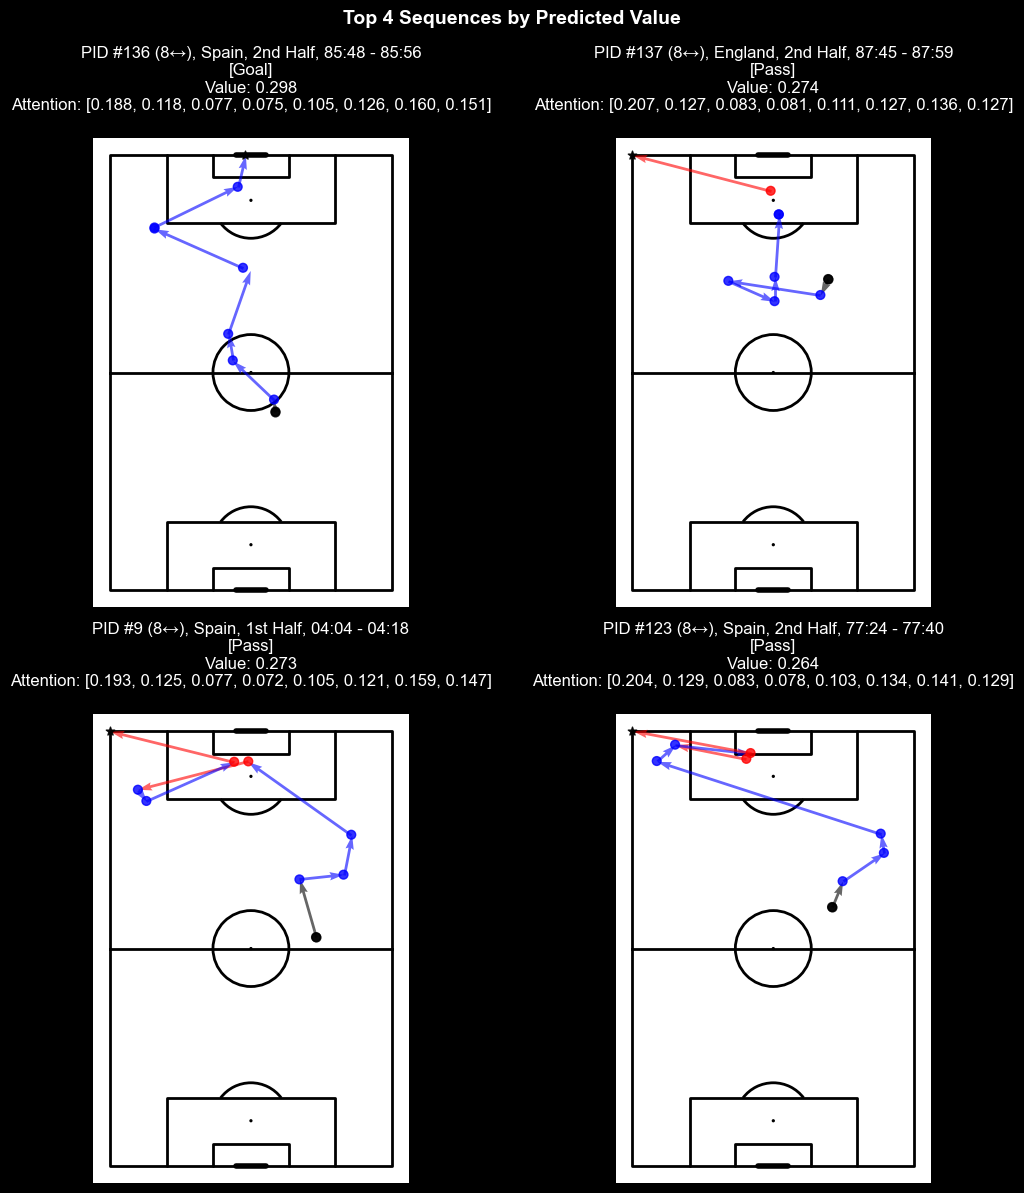

In [49]:
visualize_top_sequences(p, predicted_values, attention_weights, head=4, cols=2)
plt.savefig(f"{MODEL_DIR}/top_possessions_final_{MODE.value}.png", dpi=300)


## 5. Additional Analysis

#### Analyze all possessions with predicted value above a certain threshold

In [50]:
len(p)

264

In [51]:
high_value_indices = np.where(predicted_values >= 0.07)[0]
len(high_value_indices)

33

Processed sequence index: 12 with predicted value: 0.273
Processed sequence index: 36 with predicted value: 0.087
Processed sequence index: 39 with predicted value: 0.163
Processed sequence index: 40 with predicted value: 0.145
Processed sequence index: 43 with predicted value: 0.243
Processed sequence index: 47 with predicted value: 0.110
Processed sequence index: 52 with predicted value: 0.100
Processed sequence index: 55 with predicted value: 0.236
Processed sequence index: 68 with predicted value: 0.160
Processed sequence index: 70 with predicted value: 0.100
Processed sequence index: 72 with predicted value: 0.137
Processed sequence index: 97 with predicted value: 0.238
Processed sequence index: 104 with predicted value: 0.250
Processed sequence index: 126 with predicted value: 0.228
Processed sequence index: 131 with predicted value: 0.169
Processed sequence index: 132 with predicted value: 0.081
Processed sequence index: 137 with predicted value: 0.198
Processed sequence index: 

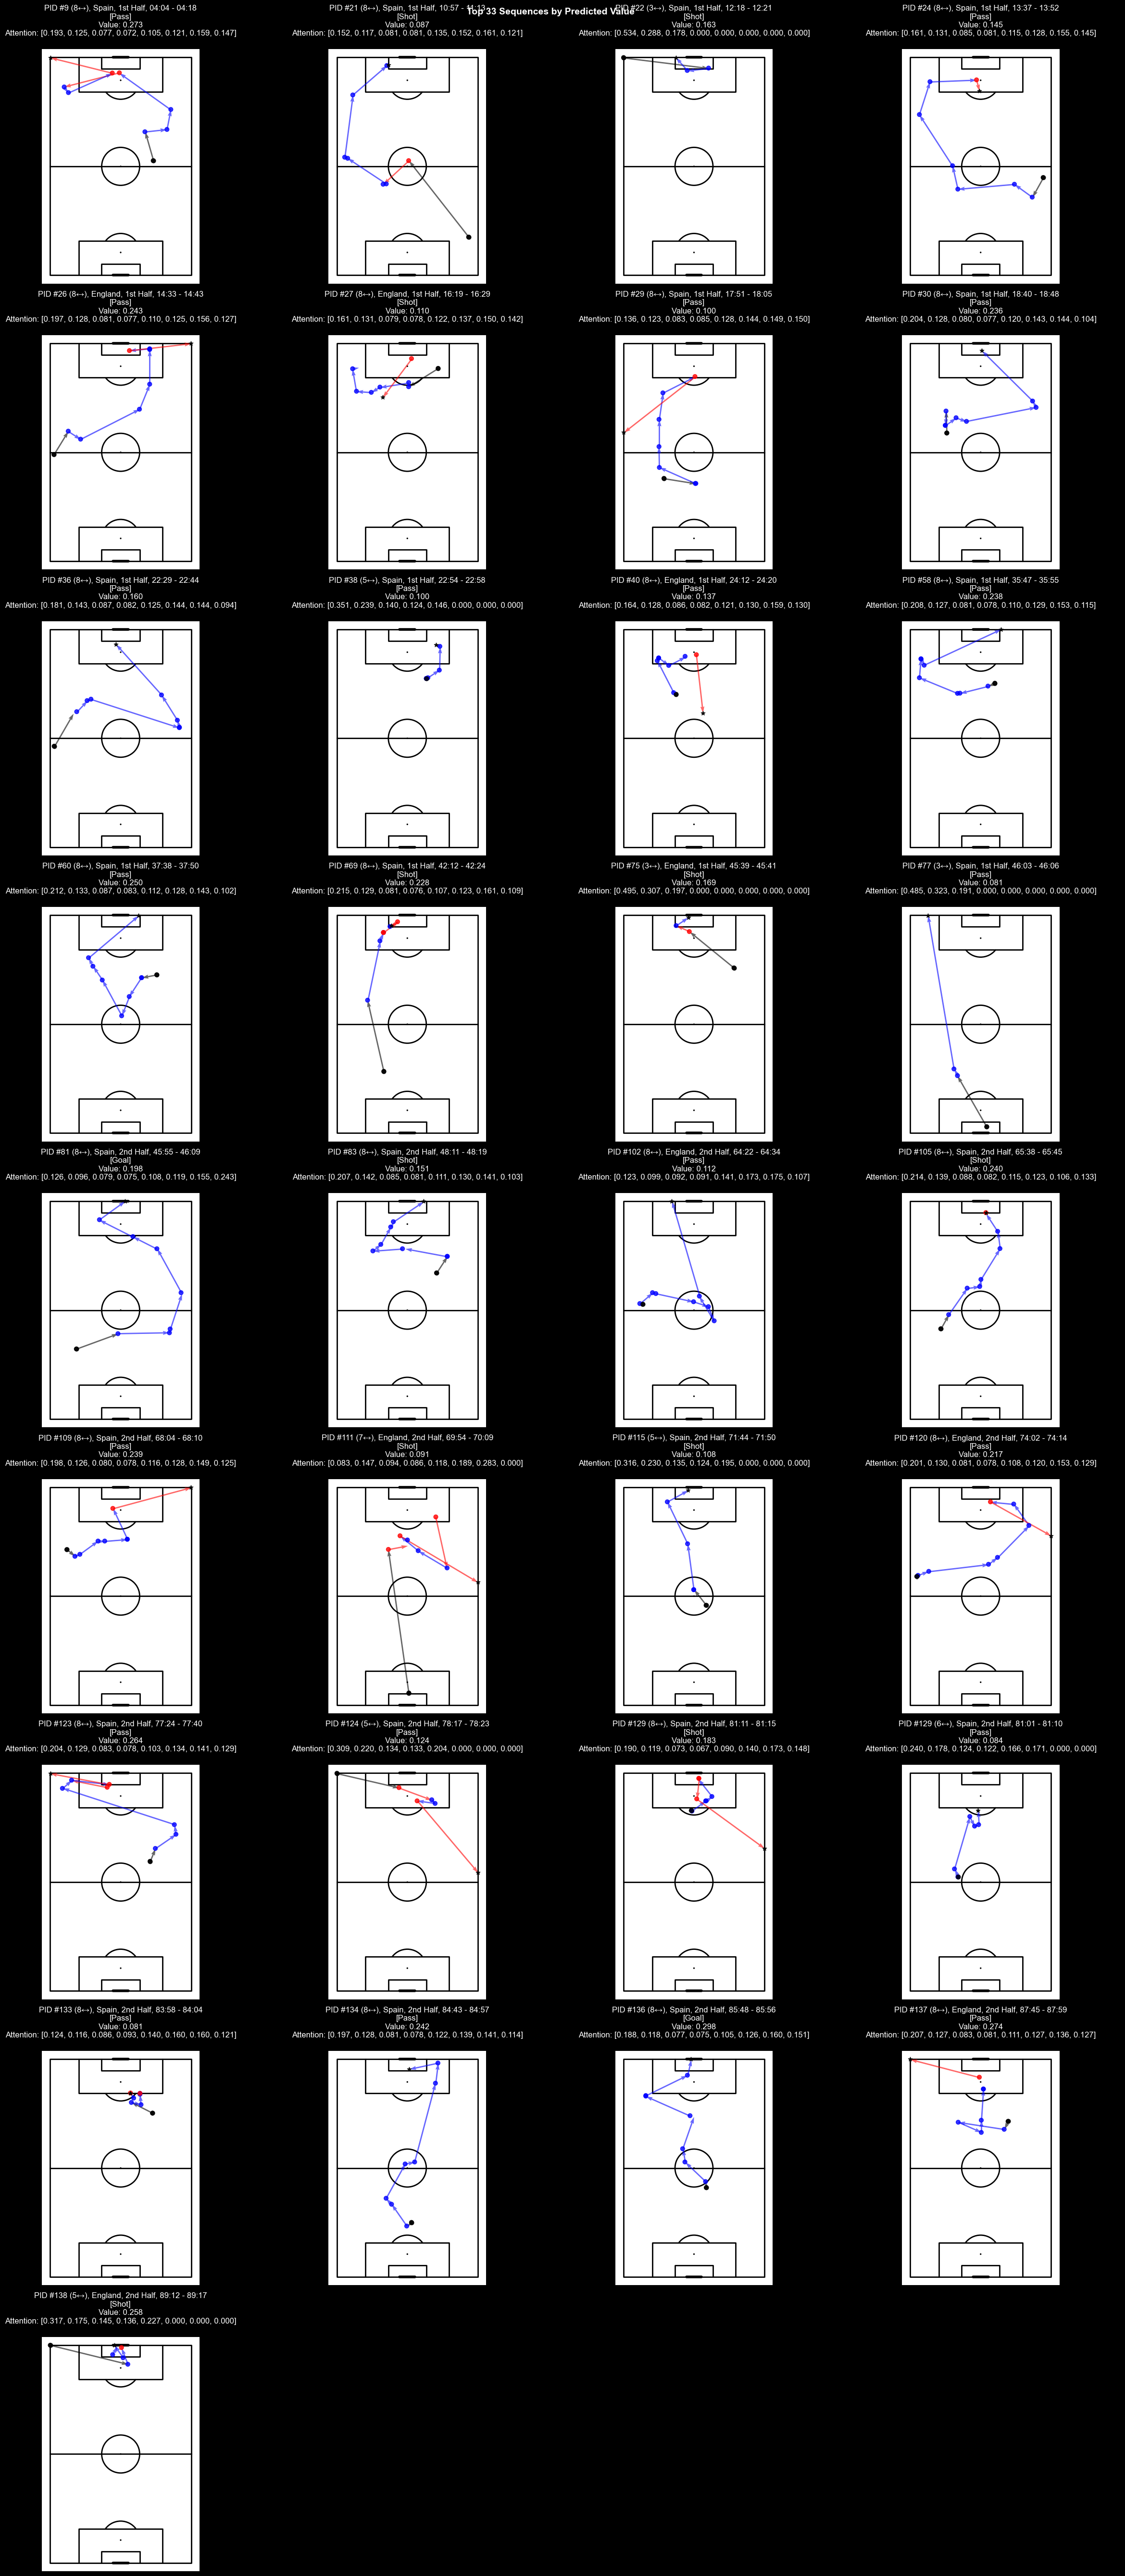

In [52]:
visualize_top_sequences(p, predicted_values, attention_weights, indices=high_value_indices, cols=4)
None

#### Analyse specific possession by index

In [53]:
top_indices = get_top_indices(predicted_values)

IDs of possessions:  [36, 37, 38, 131, 137, 138, 139, 141, 142, 143, 166, 167, 168, 169, 191, 192, 197, 210, 211, 212, 238, 239, 256, 257, 260]
Processed sequence index: 36 with predicted value: 0.087
Processed sequence index: 37 with predicted value: 0.011
Processed sequence index: 38 with predicted value: 0.010
Processed sequence index: 131 with predicted value: 0.169
Processed sequence index: 137 with predicted value: 0.198
Processed sequence index: 138 with predicted value: 0.013
Processed sequence index: 139 with predicted value: 0.012
Processed sequence index: 141 with predicted value: 0.151
Processed sequence index: 142 with predicted value: 0.020
Processed sequence index: 143 with predicted value: 0.011
Processed sequence index: 166 with predicted value: 0.055
Processed sequence index: 167 with predicted value: 0.066
Processed sequence index: 168 with predicted value: 0.022
Processed sequence index: 169 with predicted value: 0.017
Processed sequence index: 191 with predicted va

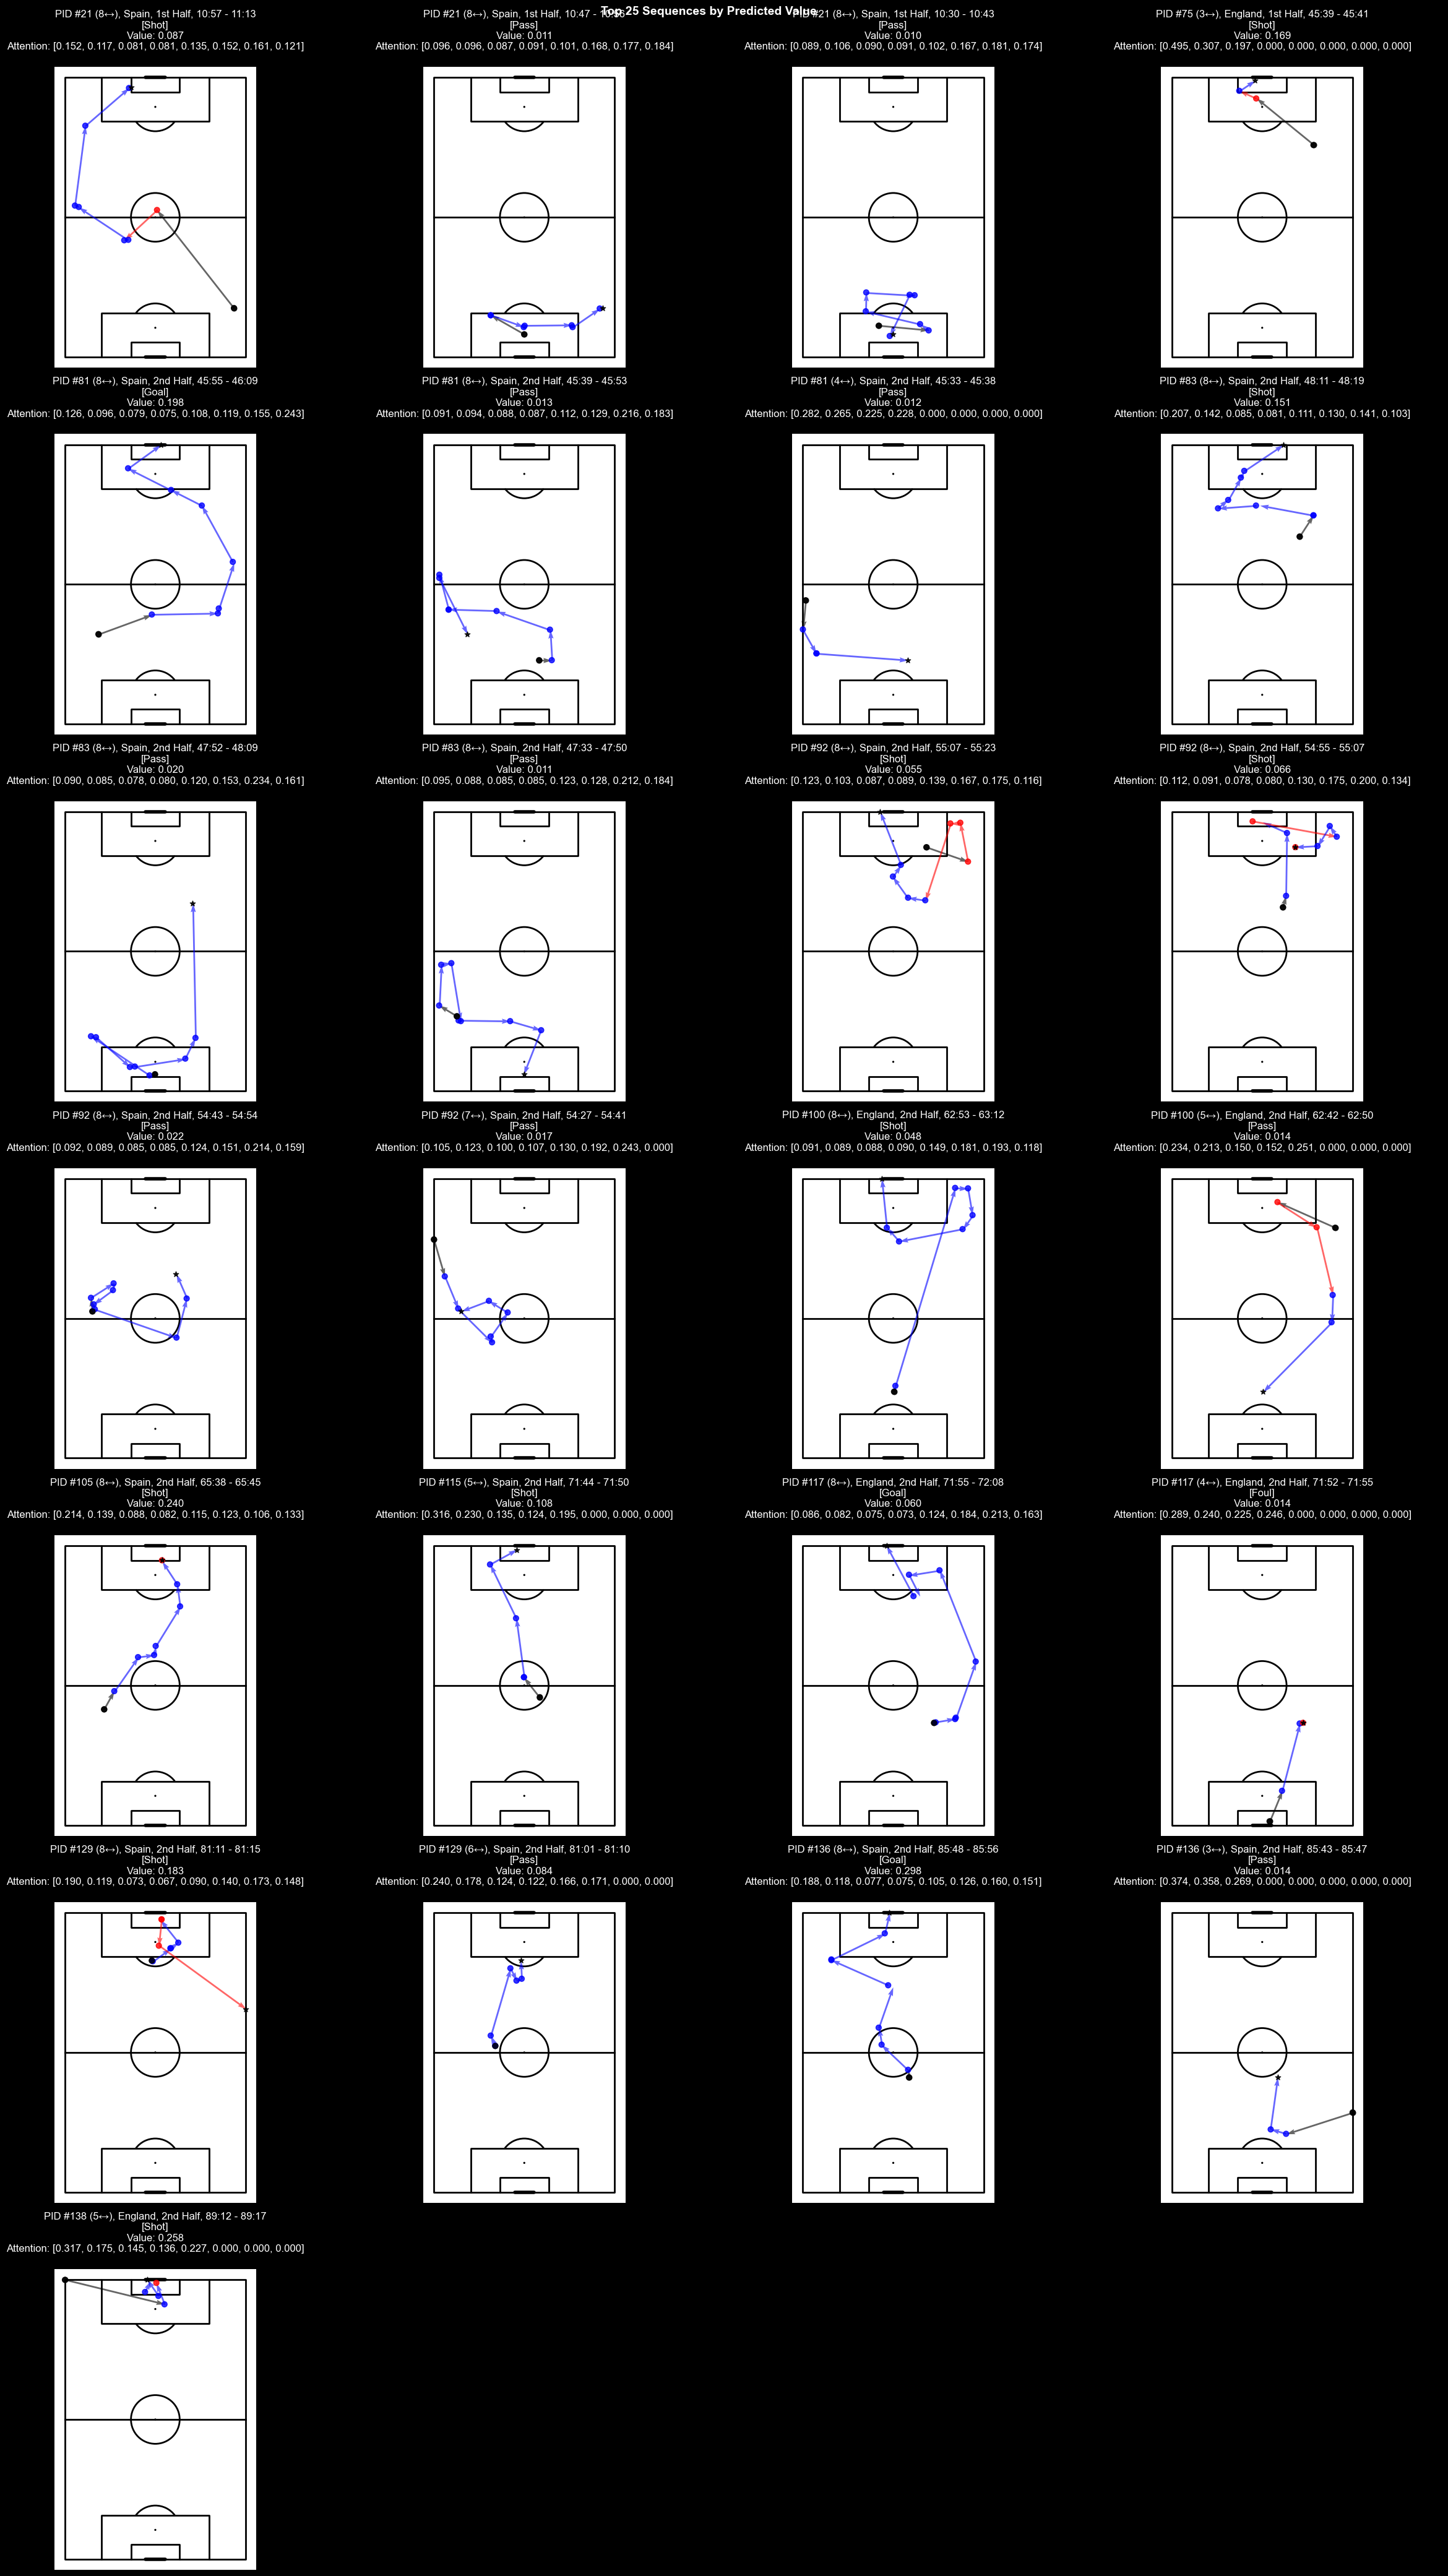

In [54]:
possession_ids = [
    21,
    75,
    81,
    83,
    # brakuje, która jest częścią 92
    92,
    100,
    105,
    115,
    117,
    129,
    136,
    138,
]
indices = [i for i, df in enumerate(p) if df['possession'].iloc[0] in possession_ids]
print("IDs of possessions: ", indices)
visualize_top_sequences(p, predicted_values, attention_weights, indices=np.array(indices), cols=4)
for idx in indices:
    print(f"Possession ID: {p[idx]['possession'].iloc[0]}")
    print(p[idx][['type_name', 'player_name', 'xG', 'xT']])
# None
# # plot_possession_actions(p[possession_id])
# # p[possession_id][['type_name', 'player_name', 'xG', 'xT']]

#### Analyze another possession

In [55]:
p[49][['possession', 'type_name', 'player_name', 'xG', 'xT']]

,possession,type_name,player_name,xG,xT
332,27,Carry,Declan Rice,0.0,0.012626
333,27,Pass,Declan Rice,0.0,0.014291
334,27,Carry,John Stones,0.0,0.013845
335,27,Pass,John Stones,0.0,0.019351
336,27,Carry,Phil Foden,0.0,0.019351
337,27,Pass,Phil Foden,0.0,0.016856
338,27,Carry,Kobbie Mainoo,0.0,0.016856
339,27,Pass,Kobbie Mainoo,0.0,0.012483


#### Analyse problematic possession

In [68]:
pipp_260 = p[260][['possession', 'type_name', 'player_name', 'xG', 'xT']].copy()
attention_weights_260 = attention_weights[260][:len(pipp_260)]
pipp_260['transformer_weight'] = [0.030595, 0.057300, 0.899807, 0.001545, 0.010754]
pipp_260[f'{MODEL_TYPE}_weight'] = attention_weights_260
pipp_260.style.hide(axis='index')


possession,type_name,player_name,xG,xT,transformer_weight,attention_lstm_weight
138,Pass,Cole Palmer,0.000000,0.037926,0.030595,0.317062
138,Shot,Declan Rice,0.057442,0.108051,0.057300,0.175245
138,Goal Keeper,Unai Simón Mendibil,0.000000,0.257454,0.899807,0.144691
138,Shot,Marc Guehi,0.117154,0.257454,0.001545,0.136098
138,Shot,Declan Rice,0.105782,0.257454,0.010754,0.226904


#### Find sequences with length less then SEQUENCE_LENGTH

In [57]:
p[0]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
0,3943043,152820f0-6ca9-4df3-943b-a67d568ff472,1,0.340,768,99174.0,52.45625,34.0425,22.18125,35.0625,0,1,5,0,England,Kobbie Mainoo,2,Pass,2.529454,False,False,0.0,768,England,0.010165,-30.2750,1.020,30.292178,3.107914,0.000,0
1,3943043,9c107df3-a3c8-4ad5-bc35-00214087a105,1,2.870,768,3468.0,22.18125,35.0625,25.06875,41.1825,21,1,0,1,England,Jordan Pickford,2,Carry,1.872089,False,False,0.0,768,England,0.010165,2.8875,6.120,6.766983,1.129951,2.530,0
2,3943043,237201b8-aef8-4823-b282-e82875795c07,1,4.742,768,3468.0,25.06875,41.1825,104.95625,10.4975,0,0,4,2,England,Jordan Pickford,2,Pass,5.137795,False,False,0.0,768,England,0.046477,79.8875,-30.685,85.577929,-0.366727,1.872,0


In [58]:
short_sequence_ids = np.array([i for i, df in enumerate(p) if len(df) < config.SEQUENCE_LENGTH])
print(f"IDs of short sequences: {short_sequence_ids}")

IDs of short sequences: [  0   4   6  10  16  17  28  30  31  33  39  42  44  51  57  64  66  67
  69  70  71  73  74  81  85  91  92  96 102 103 108 115 119 121 123 127
 128 129 131 132 133 136 139 140 146 148 150 151 158 165 169 170 174 186
 190 192 193 195 196 198 199 200 203 204 209 210 212 214 217 219 220 229
 233 236 237 239 243 244 245 252 255 257 259 260 261 262 263]


#### Create X_short_sequences and p_short_sequences

In [59]:
X_short_sequences = X[short_sequence_ids]
p_short_sequences = p[short_sequence_ids]

print(f"X_short_sequences shape: {X_short_sequences.shape}")
print(f"Number of short sequences: {len(p_short_sequences)}")

X_short_sequences shape: (87, 8, 46)
Number of short sequences: 87


#### Make predictions on short sequences

In [60]:
predictions_short = model.predict(X_short_sequences, batch_size=32, verbose=0)
predicted_values_short, attention_weights_short = normalize_predictions(predictions_short)

print(f"Total short sequences analyzed: {len(predicted_values_short)}")
print(f"Sum of predicted values: {predicted_values_short.sum():.3f}")
print(f"Has attention weights: {attention_weights_short is not None}")

Total short sequences analyzed: 87
Sum of predicted values: 2.785
Has attention weights: True


#### Visualize short sequences

Processed sequence index: 83 with predicted value: 0.258
Processed sequence index: 38 with predicted value: 0.169
Processed sequence index: 10 with predicted value: 0.163
Processed sequence index: 71 with predicted value: 0.124
Processed sequence index: 65 with predicted value: 0.108
Processed sequence index: 19 with predicted value: 0.100
Processed sequence index: 63 with predicted value: 0.091
Processed sequence index: 75 with predicted value: 0.084


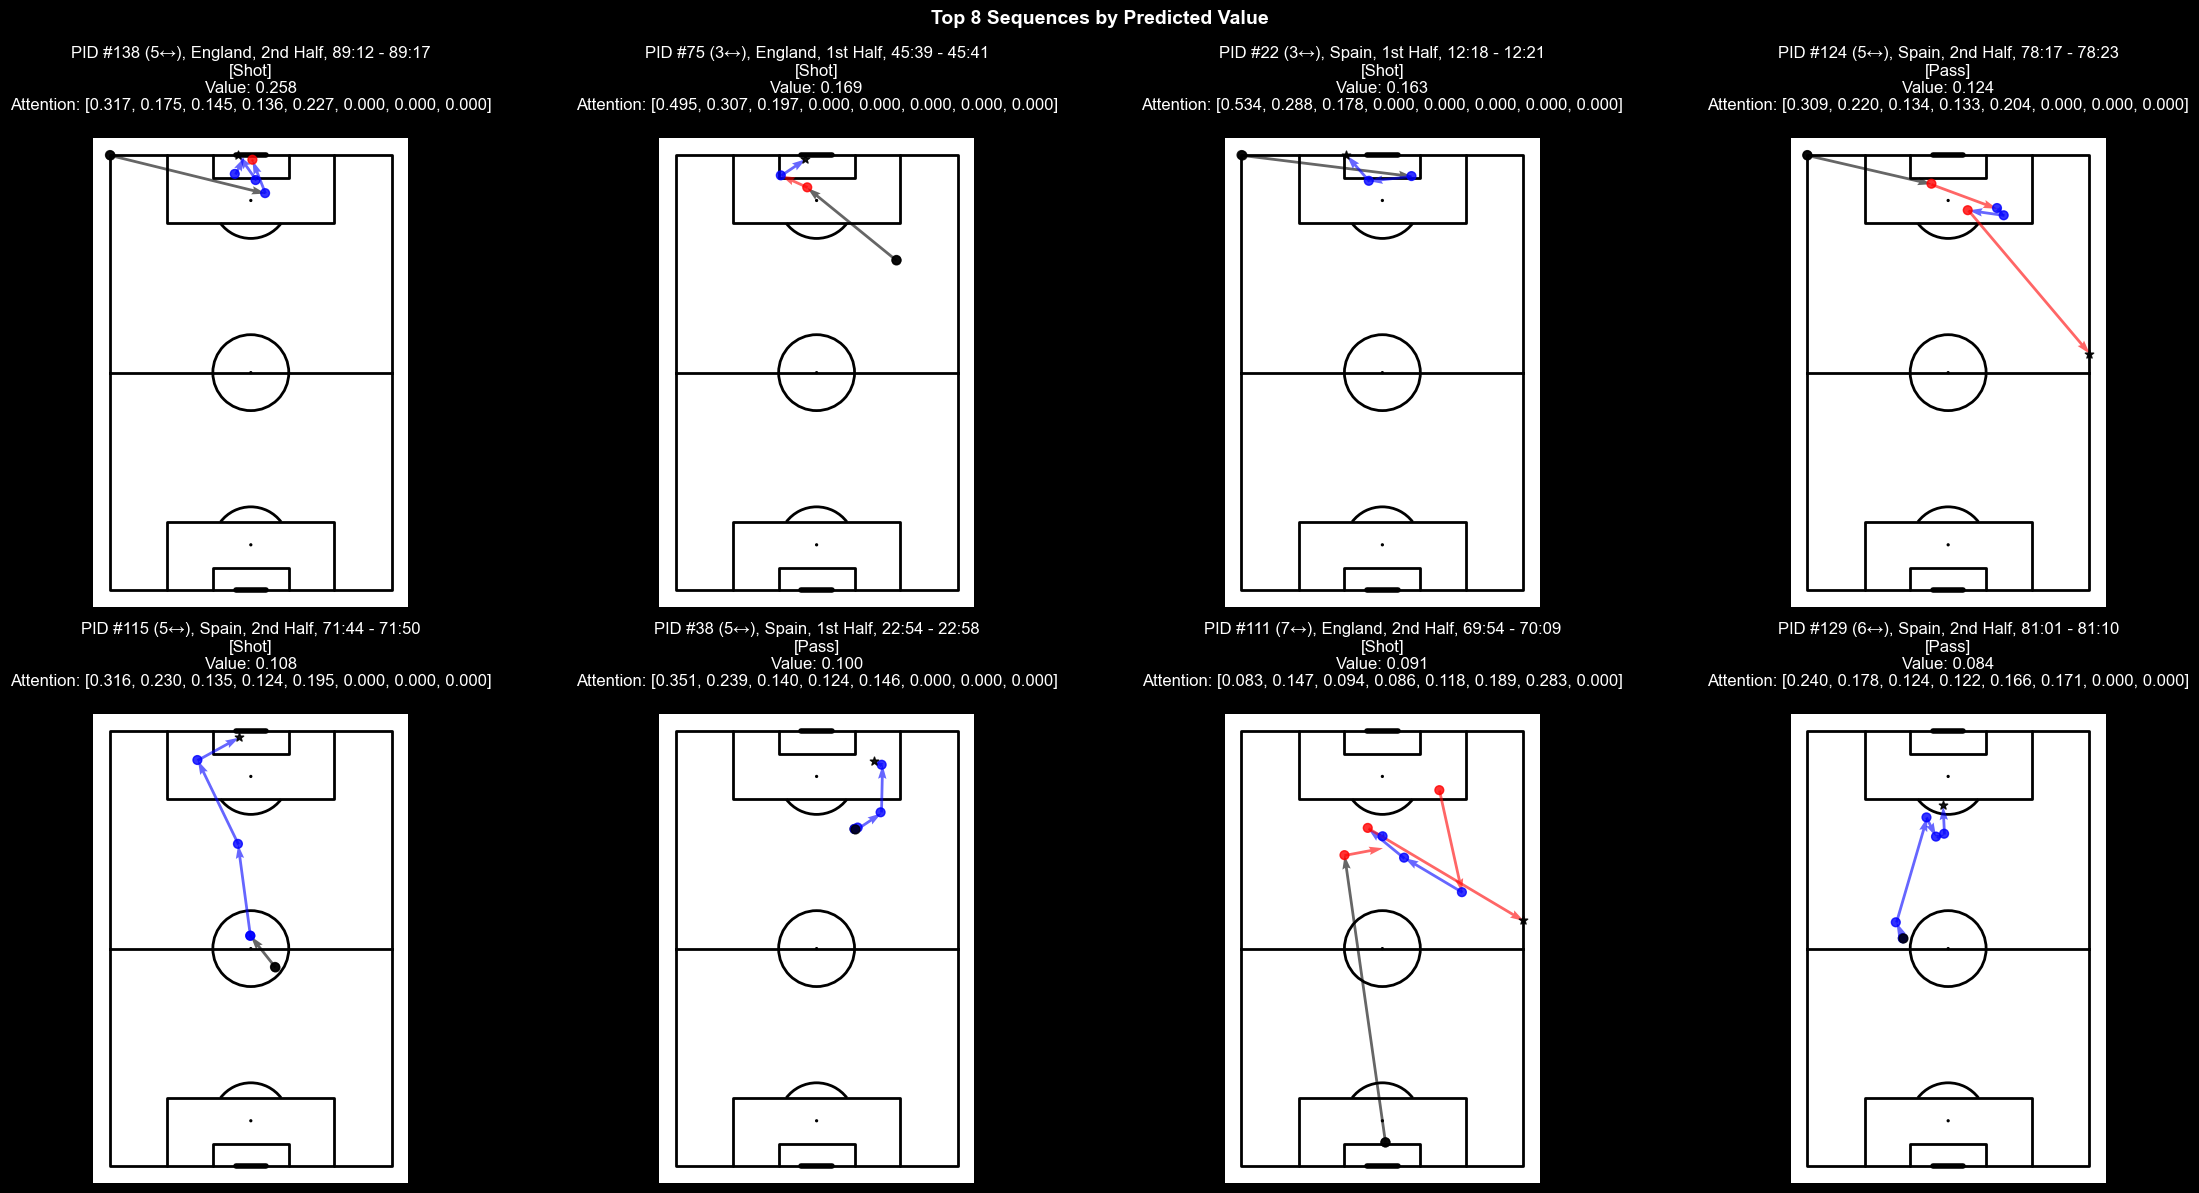

In [61]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, 8, cols=4)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_short_sequences_{MODE.value}.png", dpi=300)


#### Get top indices from short sequences

In [62]:
top_indices_short = get_top_indices(predicted_values_short)
top_indices_short

array([83, 38, 10, 71, 65, 19, 63, 75, 39, 28,  4, 70,  0, 60, 59, 86, 76,
       43, 69, 54, 62, 78, 84, 16, 29, 21, 25, 82, 33, 34, 30,  7, 20, 47,
       45, 32, 58,  1, 12, 64, 15, 57, 14, 53, 74, 49, 50, 56, 31, 68,  9,
       46, 79, 11, 22, 17, 66, 81, 55, 41,  3, 48, 80, 23, 85, 27, 35, 40,
        8, 67,  5, 37, 73, 61, 51, 13, 72,  2, 42, 24, 26, 52, 77, 18, 44,
       36,  6])

Processed sequence index: 35 with predicted value: 0.014


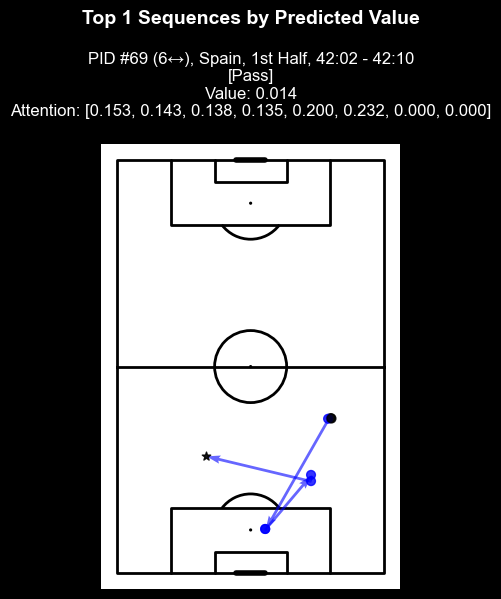

In [63]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, indices=np.array([35]))
None

In [64]:
p_short_sequences[35]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
922,3943043,df001901-e05e-424c-b847-4e8bb7260b7f,1,2522.167,772,4353.0,39.41875,13.6425,39.24375,14.3225,21,1,0,922,Spain,Aymeric Laporte,69,Carry,0.727696,False,False,0.0,772,Spain,0.012147,-0.1750,0.680,0.702157,1.822683,0.000,0
923,3943043,c6a690bc-cdbc-45b4-b50e-91b1420b07ef,1,2522.895,772,4353.0,39.24375,14.3225,11.24375,30.3025,0,1,5,923,Spain,Aymeric Laporte,69,Pass,2.975265,False,False,0.0,772,Spain,0.010827,-28.0000,15.980,32.239113,2.622985,0.728,0
924,3943043,6e39ade8-757a-48f5-aa13-88438a4aaa53,1,2525.870,772,11748.0,11.24375,30.3025,11.24375,30.3025,21,1,0,924,Spain,Unai Simón Mendibil,69,Carry,1.273691,False,False,0.0,772,Spain,0.010827,0.0000,0.000,0.000000,0.000000,2.975,0
925,3943043,28b7c7bc-a7e0-45e2-aa9e-29bf8c404558,1,2527.143,772,11748.0,11.24375,30.3025,24.98125,18.6575,0,1,5,925,Spain,Unai Simón Mendibil,69,Pass,1.765271,False,False,0.0,772,Spain,0.010013,13.7375,-11.645,18.009024,-0.703145,1.273,0
926,3943043,4d44a792-4750-4f3c-8c89-320e583057f0,1,2528.909,772,22128.0,24.98125,18.6575,23.40625,18.6575,21,1,0,926,Spain,Robin Aime Robert Le Normand,69,Carry,1.673189,False,False,0.0,772,Spain,0.010013,-1.5750,0.000,1.575000,3.141593,1.766,0
927,3943043,9f0584a9-ab77-4210-9d49-b44535e66f2e,1,2530.582,772,22128.0,23.40625,18.6575,29.79375,45.3475,0,1,5,927,Spain,Robin Aime Robert Le Normand,69,Pass,1.959470,False,False,0.0,772,Spain,0.011105,6.3875,26.690,27.443692,1.335893,1.673,0


In [65]:
X_short_sequences[35]

array([[ 3.75416666e-01,  2.00625002e-01,  3.73750001e-01,
         2.10624993e-01,  6.68721320e-03,  9.68443871e-01,
        -2.49231875e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 3.73750001e-01,  2.10624993e-01,  1.07083336e-01,
         4.45625007e-01,  3.07

In [66]:
attention_weights_short[35]

array([0.1525563 , 0.14274164, 0.1379755 , 0.13463514, 0.20048502,
       0.23160651, 0.        , 0.        ], dtype=float32)